In [1]:
import pandas as pd 

In [2]:
import plotly.express as px

In [9]:
df_calendar=pd.read_csv(r"D:\Airbnb Project\cleaned_data\calendar_cleaned.csv")

In [34]:
df_reviews=pd.read_csv(r"D:\Airbnb Project\cleaned_data\fact_reviews_clean.csv")

In [3]:
df_base=pd.read_csv(r"D:\Airbnb Project\cleaned_data\listings_base_clean.csv")

In [25]:
df_merged= pd.merge(df_base[['id',
                             'host_id',
                             'number_of_reviews',
                             'review_scores_value']], 
                    dim_host[['host_id','host_is_superhost']],
                    on='host_id')

In [26]:
df_merged['weighted_score_numerator']=df_merged['number_of_reviews']*df_merged['review_scores_value']

In [27]:
host_metrics=df_merged.groupby('host_id').agg(
    total_listings=('id','count'),
    total_numerator=('weighted_score_numerator','sum'),
    total_reviews=('number_of_reviews','sum'),
    host_is_superhost=('host_is_superhost', 'first')
).reset_index()

In [28]:
host_metrics['weighted_review_score']=host_metrics['total_numerator']/(host_metrics['total_reviews']+1e-9)

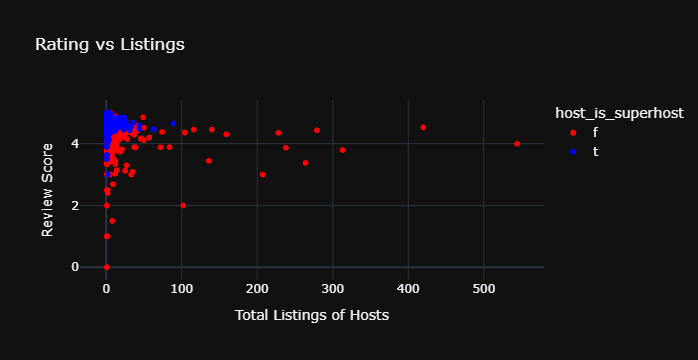

In [33]:
fig=px.scatter(
    host_metrics[host_metrics['total_reviews']!=0],
    x='total_listings',
    y='weighted_review_score',
    color='host_is_superhost',
    color_discrete_map={'f': 'red', 't': 'blue'},
    labels={'total_listings':'Total Listings of Hosts','weighted_review_score':'Review Score'},
    title='Rating vs Listings')
fig.update_layout(template='plotly_dark')
fig.show()

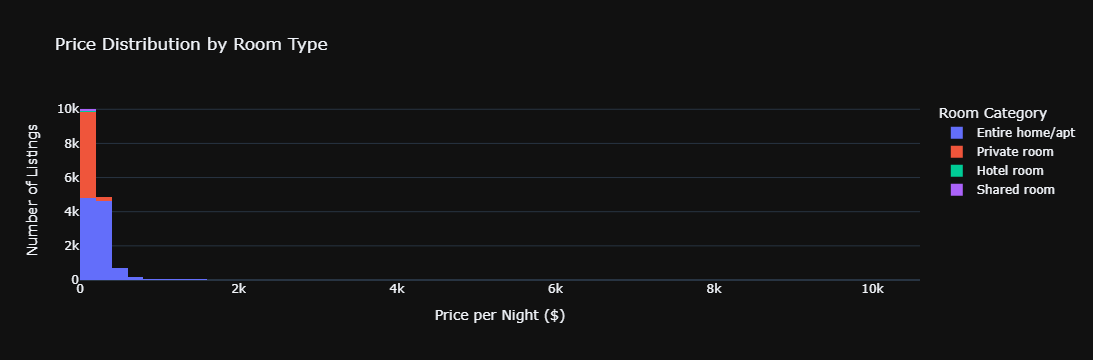

In [13]:
fig=px.histogram(
    df_base,
    x='price',
    color="room_type",
    nbins=100,
    title="Price Distribution by Room Type",
    labels={"price": "Price per Night ($)", "room_type":"Room Category"}
)
fig.update_layout(
    yaxis_title="Number of Listings",
    template="plotly_dark"
)

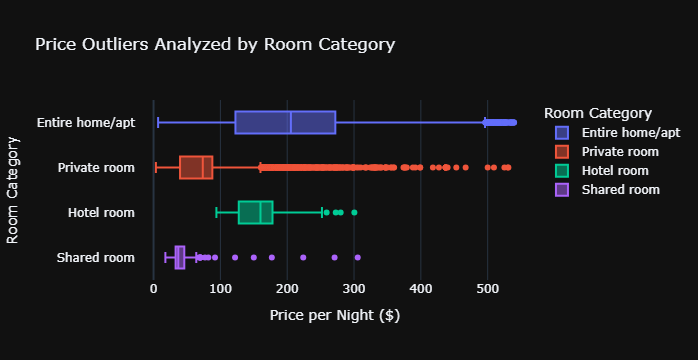

In [12]:
fig=px.box(
    df_base[df_base["price"]<540],
    x="price",
    y="room_type",
    color="room_type",
    title="Price Outliers Analyzed by Room Category",
    labels={"price": "Price per Night ($)","room_type":"Room Category"}
)
fig.update_layout(template="plotly_dark")
fig.show()

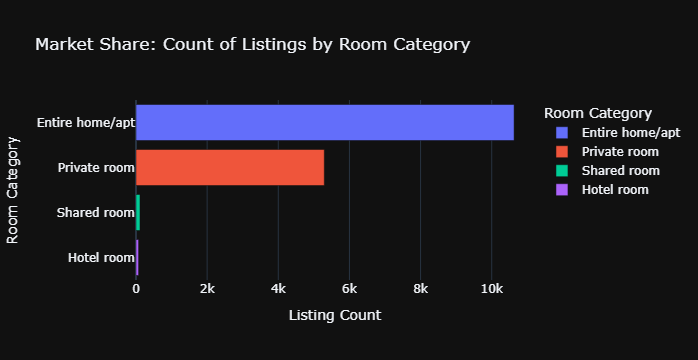

In [4]:
fig = px.bar(
    df_base['room_type'].value_counts().reset_index(),
    x="count",
    y="room_type",
    title="Market Share: Count of Listings by Room Category",
    color="room_type",
    labels={"count": "Listing Count", "room_type": "Room Category"}
)
fig.update_layout(template='plotly_dark')
fig.show()


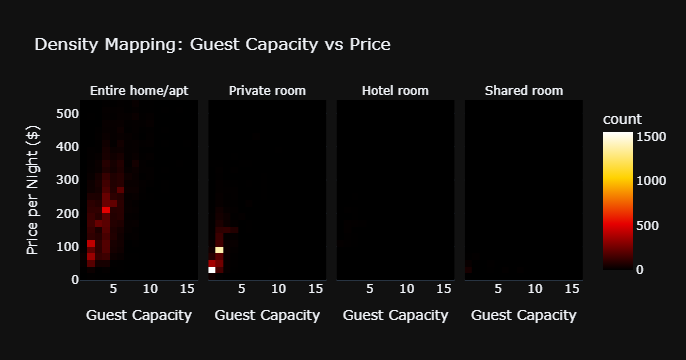

In [5]:
fig=px.density_heatmap(
    df_base[df_base["price"]<540],
    x="accommodates",
    y="price",
    facet_col="room_type",
    title="Density Mapping: Guest Capacity vs Price",
    labels={"accommodates":"Guest Capacity","price":"Price per Night ($)"},
    color_continuous_scale="Hot"
)
fig.update_layout(template="plotly_dark")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()
            

In [9]:
dim_host=pd.read_csv(r"D:\Airbnb Project\cleaned_data\listings_dim_host.csv")

In [8]:
dim_neighbourhood=pd.read_csv(r"D:\Airbnb Project\cleaned_data\listings_dim_neighbourhood.csv")
dim_neighbourhood.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   neighbourhood_id              71 non-null     int64 
 1   neighbourhood_cleansed        71 non-null     object
 2   neighbourhood_group_cleansed  71 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.8+ KB


In [6]:
df_availability=pd.read_csv(r"D:\Airbnb Project\cleaned_data\listings_fact_availability.csv")

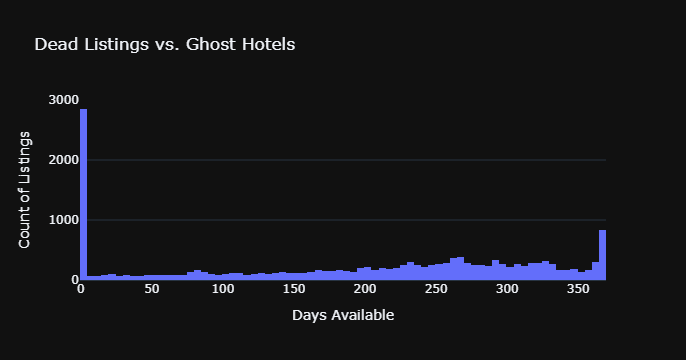

In [7]:
df_annual=df_availability[df_availability['availability_window']==365]
fig=px.histogram(
    df_annual,
    x='days_available',
    nbins=100,
    title='Dead Listings vs. Ghost Hotels',
    labels={'days_available':'Days Available'}
)
fig.update_layout(
    yaxis_title='Count of Listings',
    template='plotly_dark')
fig.show()

In [4]:
fact_host=pd.read_csv(r"D:\Airbnb Project\cleaned_data\listings_fact_host.csv")

In [6]:
fact_host.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5662 entries, 0 to 5661
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_id                                       5662 non-null   int64  
 1   last_scraped                                  5662 non-null   object 
 2   hosts_time_as_user_years                      5662 non-null   float64
 3   hosts_time_as_user_months                     5662 non-null   float64
 4   hosts_time_as_host_years                      5662 non-null   float64
 5   hosts_time_as_host_months                     5662 non-null   float64
 6   host_listings_count                           5662 non-null   float64
 7   calculated_host_listings_count                5662 non-null   int64  
 8   calculated_host_listings_count_entire_homes   5662 non-null   int64  
 9   calculated_host_listings_count_private_rooms  5662 non-null   i

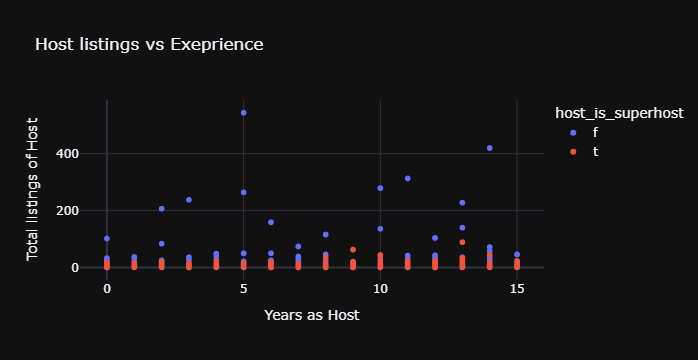

In [9]:
df_merged=pd.merge(fact_host,
                   dim_host[['host_id','host_is_superhost']],
                   on='host_id',
                   how='left'
                  )
fig=px.scatter(
    df_merged,
    x='hosts_time_as_host_years',
    y='calculated_host_listings_count',
    color='host_is_superhost',
    title='Host listings vs Exeprience',
    labels={'hosts_time_as_host_years':'Years as Host','calculated_host_listings_count': 'Total listings of Host'}
    )
fig.update_layout(template='plotly_dark')
fig.show()
    